<a href="https://colab.research.google.com/github/nhahub/NHA-5-188/blob/person-detection%2C-week-2-Malak/human_recognition_and_face_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install ultralytics opencv-contrib-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 10.8 MB/s eta 0:00:00


In [2]:
import base64
import io
import zipfile
import requests
import numpy as np
import cv2

from ultralytics import YOLO
from google.colab import files
from google.colab.output import eval_js
from IPython.display import Javascript, Image, display

person_model = YOLO("yolo11n.pt")

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
if face_detector.empty():
    raise RuntimeError("OpenCV face detector could not be loaded.")

recognizer = None
id_to_name = {}
MATCH_THRESHOLD = 80  # LBPH distance: lower means a closer match

next cell is for face identification but their is no data yet

In [ ]:
def prepare_face(gray_face):
    gray_face = cv2.resize(gray_face, (160, 160))
    return cv2.equalizeHist(gray_face)

uploaded = files.upload()
if uploaded:
    zip_name, zip_bytes = next(iter(uploaded.items()))
    train_faces = []
    train_labels = []
    name_to_id = {}

    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as archive:
        for item in archive.namelist():
            parts = item.replace("\\", "/").strip("/").split("/")
            if len(parts) < 2 or not item.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                continue

            name = parts[0]
            image_bytes = np.frombuffer(archive.read(item), dtype=np.uint8)
            photo = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
            if photo is None:
                continue

            gray = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
            faces = face_detector.detectMultiScale(
                gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
            )
            if len(faces) == 0:
                print(f"Skipped {item}: no face found")
                continue

            # Each reference photo should contain one person.
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
            if name not in name_to_id:
                name_to_id[name] = len(name_to_id)

            train_faces.append(prepare_face(gray[y:y+h, x:x+w]))
            train_labels.append(name_to_id[name])

    if not train_faces:
        raise ValueError("No usable faces found in the ZIP file.")

    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.train(train_faces, np.array(train_labels, dtype=np.int32))
    id_to_name = {number: name for name, number in name_to_id.items()}
    print(f"Trained on {len(train_faces)} photos: {list(name_to_id)}")

In [6]:
def annotate_frame(frame):
    output = frame.copy()
    height, width = frame.shape[:2]

    result = person_model.predict(
    frame, classes=[0], conf=0.35, imgsz=320, verbose=False
)[0]

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(width, x2), min(height, y2)
        if x2 <= x1 or y2 <= y1:
            continue

        person_crop = frame[y1:y2, x1:x2]
        gray = cv2.cvtColor(person_crop, cv2.COLOR_BGR2GRAY)
        faces = face_detector.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
        )

        label = "Person"
        if len(faces):
            fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
            cv2.rectangle(
                output,
                (x1 + fx, y1 + fy),
                (x1 + fx + fw, y1 + fy + fh),
                (255, 180, 0),
                2,
            )

            if recognizer is not None:
                face = prepare_face(gray[fy:fy+fh, fx:fx+fw])
                person_id, distance = recognizer.predict(face)
                label = (
                    id_to_name[person_id]
                    if distance < MATCH_THRESHOLD
                    else "Unknown"
                )
            else:
                label = "Person / face detected"

        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 220, 0), 2)
        cv2.putText(
            output, label, (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 220, 0), 2
        )

    return output

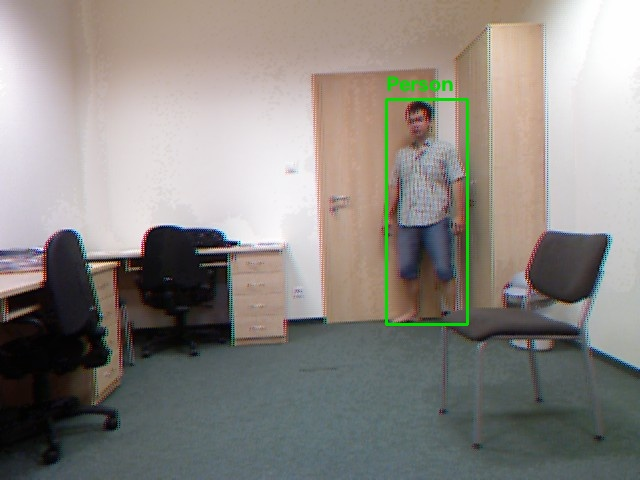

In [7]:
url = "https://fenix.ur.edu.pl/~mkepski/ds/data/fall-01-cam0-rgb.zip"
response = requests.get(url, timeout=120)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
    image_names = sorted(
        name for name in archive.namelist()
        if name.lower().endswith(".png")
    )
    if not image_names:
        raise ValueError("No PNG frames found in the dataset ZIP.")

    frame_bytes = np.frombuffer(archive.read(image_names[0]), dtype=np.uint8)
    dataset_frame = cv2.imdecode(frame_bytes, cv2.IMREAD_COLOR)

annotated = annotate_frame(dataset_frame)
display(Image(data=cv2.imencode(".jpg", annotated)[1].tobytes()))

<IPython.core.display.Javascript object>

Camera running. Use Colab's Stop button to finish.


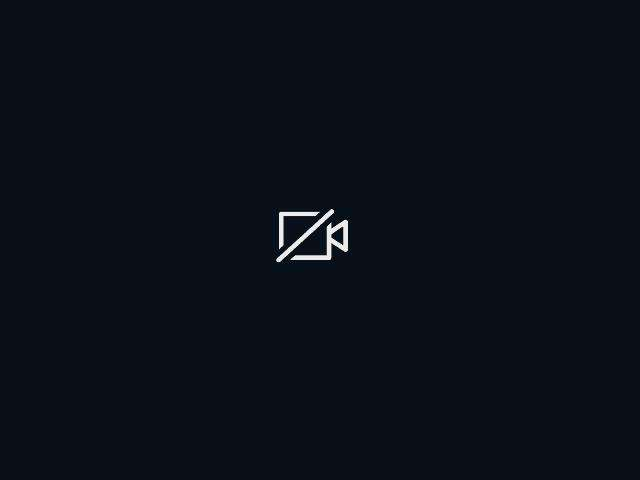

Stopped.


In [8]:
from google.colab.output import eval_js
from IPython.display import Javascript, Image, display

# Define the camera functions in the same Colab cell that uses them.
display(Javascript("""
window.startCamera = async function() {
  window.cameraStream = await navigator.mediaDevices.getUserMedia({
    video: {width: 640, height: 480},
    audio: false
  });

  window.cameraVideo = document.createElement('video');
  window.cameraVideo.srcObject = window.cameraStream;
  window.cameraVideo.autoplay = true;
  window.cameraVideo.playsInline = true;
  window.cameraVideo.style.width = '320px';
  document.body.appendChild(window.cameraVideo);
  await window.cameraVideo.play();
};

window.captureFrame = function() {
  const canvas = document.createElement('canvas');
  canvas.width = window.cameraVideo.videoWidth;
  canvas.height = window.cameraVideo.videoHeight;
  canvas.getContext('2d').drawImage(window.cameraVideo, 0, 0);
  return canvas.toDataURL('image/jpeg', 0.75);
};

window.stopCamera = function() {
  if (window.cameraStream) {
    window.cameraStream.getTracks().forEach(track => track.stop());
  }
  if (window.cameraVideo) window.cameraVideo.remove();
  window.cameraStream = null;
  window.cameraVideo = null;
};
"""))

if eval_js("typeof window.startCamera") != "function":
    raise RuntimeError("Camera JavaScript did not load. Rerun this cell.")

frame_display = None

try:
    eval_js("window.startCamera()")
    print("Camera running. Use Colab's Stop button to finish.")

    while True:
        data_url = eval_js("window.captureFrame()")
        image_data = base64.b64decode(data_url.split(",", 1)[1])
        frame = cv2.imdecode(
            np.frombuffer(image_data, dtype=np.uint8),
            cv2.IMREAD_COLOR
        )

        annotated = annotate_frame(frame)
        jpeg = cv2.imencode(
    ".jpg", annotated, [cv2.IMWRITE_JPEG_QUALITY, 60]
)[1].tobytes()

        if frame_display is None:
            frame_display = display(Image(data=jpeg), display_id=True)
        else:
            frame_display.update(Image(data=jpeg))

except KeyboardInterrupt:
    print("Stopped.")
finally:
    try:
        eval_js(
            "typeof window.stopCamera === 'function' && window.stopCamera()"
        )
    except Exception:
        pass